**Navigation:**  
[← Superspreader Party Crawl](06_superspreader_party_crawl.ipynb) | [Interventions](08_interventions.ipynb) | [Timed Interventions →](09_timed_interventions.ipynb)

# Decompose $R_t$: Contact Rate and Wells-Riley Infection Probability

This notebook factors transmission into:

$$R_t \approx c_t \cdot D \cdot p_t \cdot \frac{S_t}{N}$$

and models $p_t$ with a Wells-Riley style dose equation.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

Wells-Riley decomposition for one exposure setting:

$$p_t = 1 - \exp(-\text{dose}_t), \quad \text{dose}_t = \frac{I q p_b t \cdot \phi_\text{mask}}{Q_\text{eff} \cdot \phi_\text{mix}}$$

In [6]:
def wells_riley_probability(
    infectious_people: float,
    quanta_emission_rate: float,
    breathing_rate: float,
    exposure_hours: float,
    clean_air_rate: float,
    mask_exhale_eff: float = 0.0,
    mask_inhale_eff: float = 0.0,
    mixing_factor: float = 1.0,
) -> tuple[float, float]:
    phi_mask = (1.0 - mask_exhale_eff) * (1.0 - mask_inhale_eff)
    effective_denominator = max(clean_air_rate * mixing_factor, 1e-12)
    dose = infectious_people * quanta_emission_rate * breathing_rate * exposure_hours * phi_mask / effective_denominator
    p_inf = 1.0 - np.exp(-dose)
    return float(p_inf), float(dose)


def rt_from_contact_probability(
    contact_rate_per_day: float,
    infectious_duration_days: float,
    p_infection_per_contact: float,
    susceptible_fraction: float,
) -> float:
    return float(contact_rate_per_day * infectious_duration_days * p_infection_per_contact * susceptible_fraction)

In [7]:
contact_rate = 14.0
infectious_duration = 5.0
susceptible_fraction = 0.72

I = 1.0
q = 45.0
p_breath = 0.60
exposure_h = 3.0
Q_eff = 1600.0
mask_exhale = 0.40
mask_inhale = 0.30
mixing = 1.0

p_inf, dose = wells_riley_probability(
    infectious_people=I,
    quanta_emission_rate=q,
    breathing_rate=p_breath,
    exposure_hours=exposure_h,
    clean_air_rate=Q_eff,
    mask_exhale_eff=mask_exhale,
    mask_inhale_eff=mask_inhale,
    mixing_factor=mixing,
)

Rt_example = rt_from_contact_probability(contact_rate, infectious_duration, p_inf, susceptible_fraction)

components = pd.DataFrame([
    {'component': 'c_t (contacts/day)', 'value': contact_rate},
    {'component': 'D (infectious days)', 'value': infectious_duration},
    {'component': 'S_t / N', 'value': susceptible_fraction},
    {'component': 'Wells-Riley dose', 'value': dose},
    {'component': 'p_t (per-contact infection prob)', 'value': p_inf},
    {'component': 'R_t', 'value': Rt_example},
])

display(components)
print(f'Wells-Riley p_t = {p_inf:.4f}, dose = {dose:.4f}')
print(f'R_t decomposition result = {Rt_example:.3f}')

,component,value
0,c_t (contacts/day),14.000000
1,D (infectious days),5.000000
2,S_t / N,0.720000
3,Wells-Riley dose,0.021262
4,p_t (per-contact infection prob),0.021038
5,R_t,1.060318


Wells-Riley p_t = 0.0210, dose = 0.0213
R_t decomposition result = 1.060


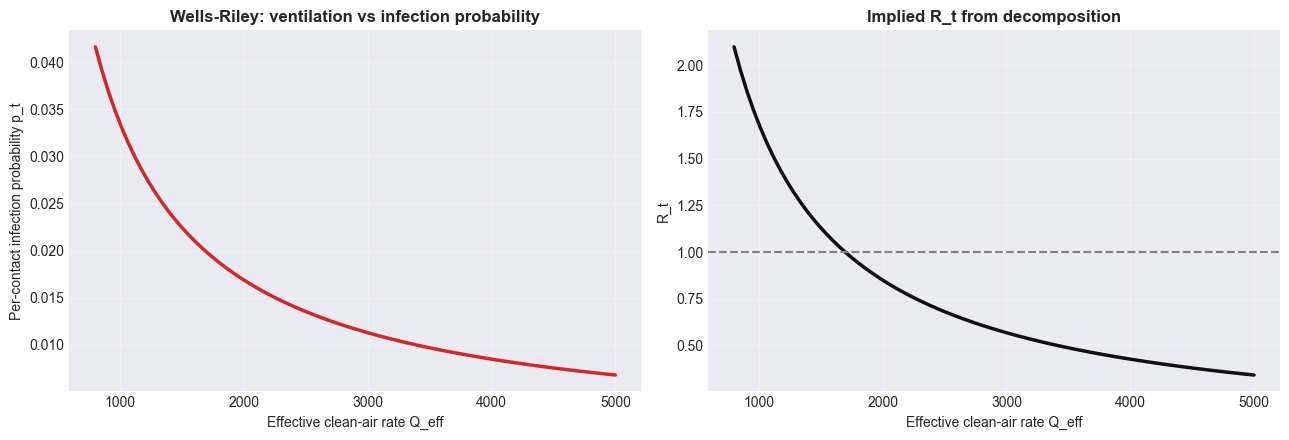

In [8]:
Q_values = np.linspace(800, 5000, 80)
p_values = []
rt_values = []
for Q in Q_values:
    p_q, _ = wells_riley_probability(I, q, p_breath, exposure_h, Q, mask_exhale, mask_inhale)
    p_values.append(p_q)
    rt_values.append(rt_from_contact_probability(contact_rate, infectious_duration, p_q, susceptible_fraction))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(Q_values, p_values, linewidth=2.5, color='#d62728')
axes[0].set_xlabel('Effective clean-air rate Q_eff')
axes[0].set_ylabel('Per-contact infection probability p_t')
axes[0].set_title('Wells-Riley: ventilation vs infection probability', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(Q_values, rt_values, linewidth=2.5, color='#111111')
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Effective clean-air rate Q_eff')
axes[1].set_ylabel('R_t')
axes[1].set_title('Implied R_t from decomposition', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()